# Machine Learning–Based Trading Strategies for Metal Futures
Author : Darshit Shah

## Project Overview
This project evaluates whether simple machine learning models can generate economically meaningful trading signals in metal futures markets. Using daily data for COMEX Gold, Silver, and Copper over approximately 15 years, we test multiple models and translate their predictions into disciplined long/flat trading strategies.

Rather than maximizing raw predictive accuracy, the emphasis is on **out-of-sample performance**, **risk-adjusted returns**, and understanding when and why certain models work better across different assets and market regimes.

---

## Assets Covered
- **Gold Futures** – often viewed as a safe-haven asset with strong trending behavior  
- **Silver Futures** – highly volatile with sharp rallies and drawdowns  
- **Copper Futures** – cyclical and closely linked to global industrial activity  

Each asset is analyzed independently using the same feature set, models, and evaluation framework to ensure a fair comparison.

---

## Evaluation Approach
- Features are constructed using only information available up to time *t* to avoid look-ahead bias.
- Data is split chronologically:
  - First 80% for training  
  - Last 20% for out-of-sample testing  
- Model predictions are converted into **long-or-flat trading signals** (no short-selling).
- Performance is benchmarked against a buy-and-hold strategy using:
  - Directional accuracy  
  - Annualized return and volatility  
  - Sharpe ratio (0% risk-free rate)  
  - Trade statistics and drawdown behavior  

This framework prioritizes robustness, interpretability, and realistic evaluation over overly complex modeling.



## Data loading & cleaning

In [1]:
# 1. Imports and settings

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

from xgboost import XGBClassifier

import matplotlib.pyplot as plt

In [2]:
# 2. Load raw CSV files

gold_raw   = pd.read_csv("gold_15y.csv")
silver_raw = pd.read_csv("silver_15y.csv")
copper_raw = pd.read_csv("copper_15y.csv")

In [3]:
# 3. Cleaning helper
# =========================

def clean_futures_df(df):
    # Make a copy to avoid modifying the original
    df = df.copy()
    
    # Convert Date column to datetime
    df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y")
    
    # Convert price columns to floats and remove commas if they exist
    for col in ["Price", "Open", "High", "Low"]:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(",", "", regex=False)
            .astype(float)
        )
    
    # Convert volume like "1.23K" or "0.25M" to numeric values
    def parse_volume(x):
        x = str(x).strip()
        if x == "" or x.lower() in ["nan", "none"]:
            return np.nan
        x = x.replace(",", "")
        multiplier = 1.0
        if x.endswith("K"):
            multiplier = 1000.0
            x = x[:-1]
        elif x.endswith("M"):
            multiplier = 1_000_000.0
            x = x[:-1]
        try:
            return float(x) * multiplier
        except ValueError:
            return np.nan
    
    df["Volume"] = df["Vol."].map(parse_volume)
    
    # Convert "Change %" like "1.77%" to decimal 0.0177
    df["ChangePct"] = (
        df["Change %"]
        .astype(str)
        .str.replace("%", "", regex=False)
        .str.strip()
    )
    df["ChangePct"] = pd.to_numeric(df["ChangePct"], errors="coerce") / 100.0
    
    # Sort by date ascending
    df = df.sort_values("Date").reset_index(drop=True)
    
    # Rename columns to standard names
    df = df.rename(columns={
        "Date":  "date",
        "Price": "close",
        "Open":  "open",
        "High":  "high",
        "Low":   "low"
    })
    
    # Return only the columns we need
    return df[["date", "open", "high", "low", "close", "Volume", "ChangePct"]]


# Apply cleaning to each metal
gold   = clean_futures_df(gold_raw)
silver = clean_futures_df(silver_raw)
copper = clean_futures_df(copper_raw)

## Exploratory plots (price/volume)

In [4]:
# tables to help understand the cleaned data

print("Gold data range:",   gold["date"].min(),   "to", gold["date"].max(),   "n =", len(gold))
print("Silver data range:", silver["date"].min(), "to", silver["date"].max(), "n =", len(silver))
print("Copper data range:", copper["date"].min(), "to", copper["date"].max(), "n =", len(copper))

print("\nGold head:")
print(gold.head())

print("\nSilver head:")
print(silver.head())

print("\nCopper head:")
print(copper.head())

print("\nGold summary stats:")
print(gold[["open", "high", "low", "close", "Volume"]].describe())

print("\nSilver summary stats:")
print(silver[["open", "high", "low", "close", "Volume"]].describe())

print("\nCopper summary stats:")
print(copper[["open", "high", "low", "close", "Volume"]].describe())


Gold data range: 2010-12-01 00:00:00 to 2025-12-01 00:00:00 n = 3831
Silver data range: 2010-12-01 00:00:00 to 2025-12-01 00:00:00 n = 3885
Copper data range: 2010-12-01 00:00:00 to 2025-12-01 00:00:00 n = 3870

Gold head:
        date    open    high     low   close    Volume  ChangePct
0 2010-12-01  1387.7  1398.3  1383.0  1388.3  163760.0     0.0016
1 2010-12-02  1387.6  1399.7  1383.8  1389.3  134390.0     0.0007
2 2010-12-03  1387.1  1417.0  1385.3  1406.2  159640.0     0.0122
3 2010-12-06  1415.1  1429.4  1409.8  1416.1  144120.0     0.0070
4 2010-12-07  1426.0  1432.5  1396.7  1409.0  206640.0    -0.0050

Silver head:
        date    open    high     low   close    Volume  ChangePct
0 2010-12-01  28.180  28.880  28.020  28.413   66090.0     0.0071
1 2010-12-02  28.470  29.080  28.330  28.572   64730.0     0.0056
2 2010-12-03  28.625  29.490  28.595  29.271   59920.0     0.0245
3 2010-12-06  29.550  30.355  29.480  29.735   79170.0     0.0159
4 2010-12-07  30.200  30.750  28.485 

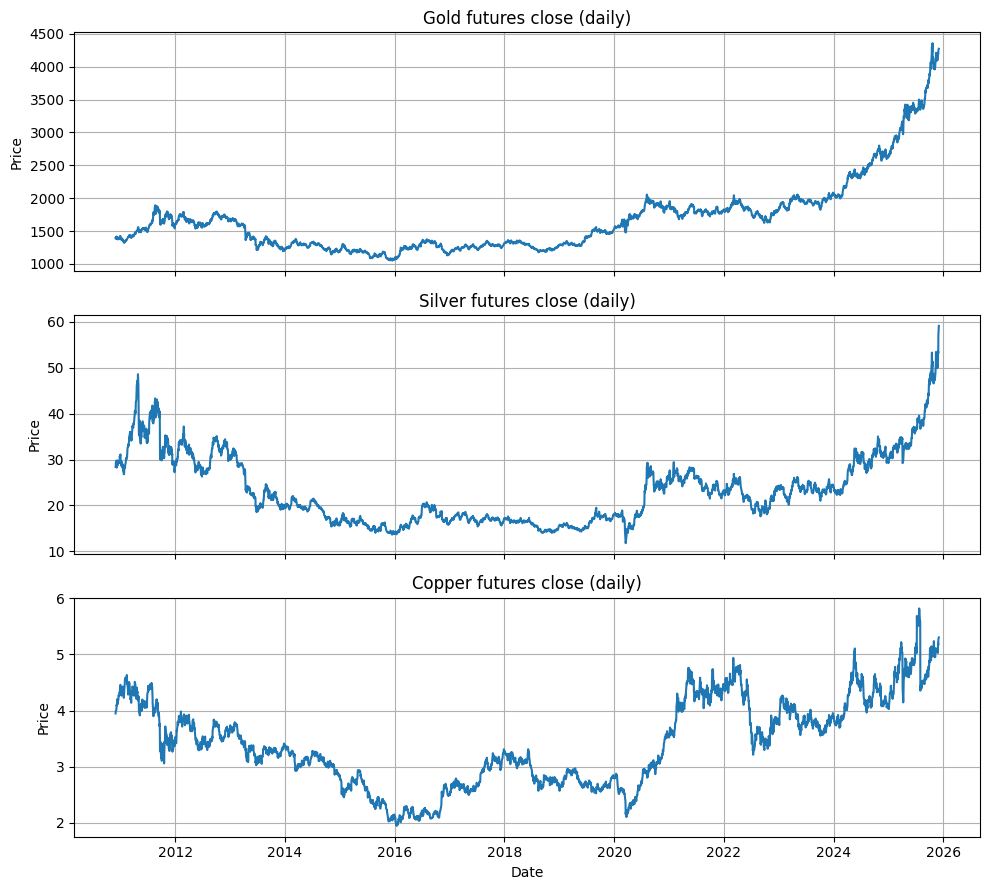

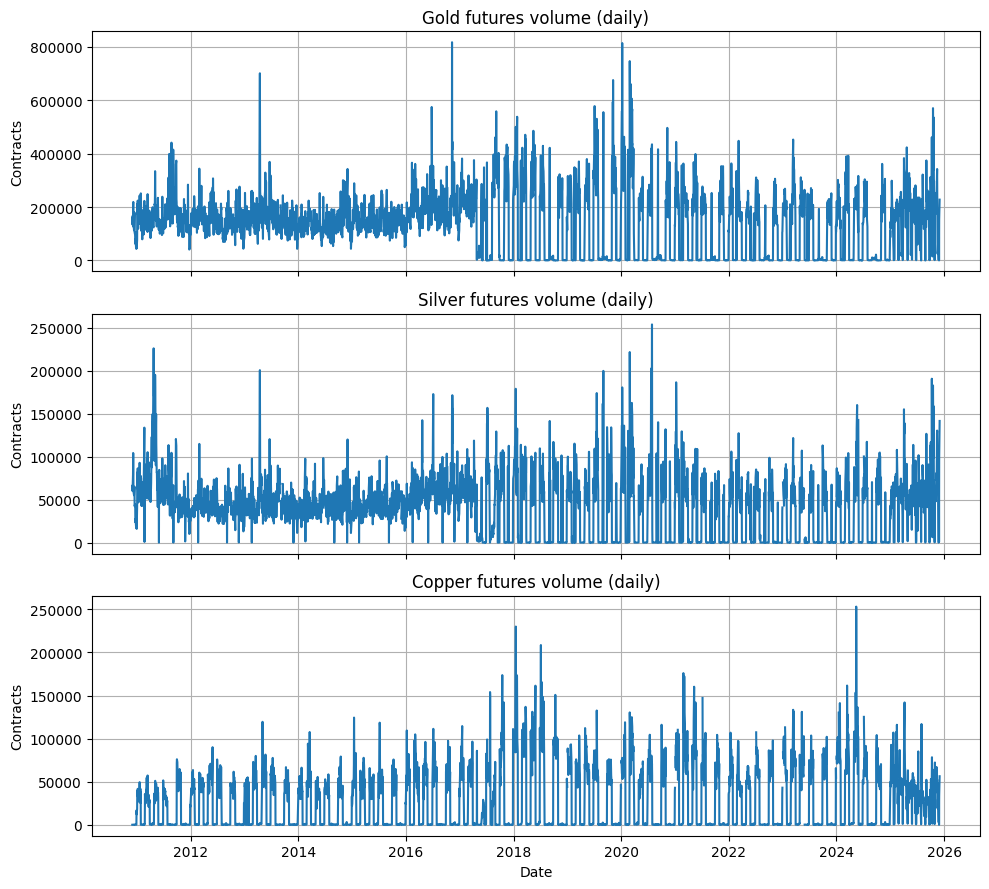

In [5]:
# visualization of cleaned data
# Price time series for each metal

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

for ax, (name, df) in zip(
    axes,
    [("Gold", gold), ("Silver", silver), ("Copper", copper)]
):
    ax.plot(df["date"], df["close"])
    ax.set_title(f"{name} futures close (daily)")
    ax.set_ylabel("Price")
    ax.grid(True)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

# Volume time series for each metal

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

for ax, (name, df) in zip(
    axes,
    [("Gold", gold), ("Silver", silver), ("Copper", copper)]
):
    ax.plot(df["date"], df["Volume"])
    ax.set_title(f"{name} futures volume (daily)")
    ax.set_ylabel("Contracts")
    ax.grid(True)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

## Feature engineering & feature inspection

In [6]:
# 4. Feature engineering
def make_features(df, asset_name):
    # Work on a copy to keep things clean
    df = df.copy()
    
    # Basic returns
    df["ret_1d"] = df["close"].pct_change()
    df["ret_5d"] = df["close"].pct_change(5)
    
    # Moving averages for trend
    df["ma_5"]  = df["close"].rolling(5).mean()
    df["ma_20"] = df["close"].rolling(20).mean()
    
    # how far price is from its 20-day average
    df["ma_gap"] = df["close"] - df["ma_20"]
    
    # Rolling volatility of returns
    df["vol_10"] = df["ret_1d"].rolling(10).std()
    
    # high-volatility regime dummy (1 if vol above median)
    vol_med = df["vol_10"].median()
    df["high_vol"] = (df["vol_10"] > vol_med).astype(int)
    
    # Volume-based features
    df["log_volume"] = np.log1p(df["Volume"])
    df["vol_chg_5"]  = df["Volume"].pct_change(5)
    
    # Target 1: next-day return (for regression)
    df["y_reg"] = df["ret_1d"].shift(-1)
    
    # Target 2: next-day direction (1 if next-day return > 0)
    df["y_cls"] = (df["y_reg"] > 0).astype(int)
    
    # Drop rows with NaNs due to rolling windows and last row with no next-day
    df = df.dropna().reset_index(drop=True)
    
    # Store asset name if we want to concatenate later
    df["asset"] = asset_name
    
    return df

FEATURE_COLS = [
    "ret_1d", "ret_5d",
    "ma_5", "ma_20", "ma_gap",
    "vol_10", "high_vol",
    "log_volume", "vol_chg_5"
]

gold_feat   = make_features(gold,   "gold")
silver_feat = make_features(silver, "silver")
copper_feat = make_features(copper, "copper")

/var/folders/m8/tnxmxbyn7297pn_415_zyy5h0000gn/T/ipykernel_5248/3190642019.py:26: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["vol_chg_5"]  = df["Volume"].pct_change(5)
/var/folders/m8/tnxmxbyn7297pn_415_zyy5h0000gn/T/ipykernel_5248/3190642019.py:26: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["vol_chg_5"]  = df["Volume"].pct_change(5)
/var/folders/m8/tnxmxbyn7297pn_415_zyy5h0000gn/T/ipykernel_5248/3190642019.py:26: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to c

Gold features head:
        date    ret_1d    ret_5d     ma_5     ma_20  ma_gap    vol_10  \
0 2010-12-29  0.005620  0.017785  1393.98  1392.665  20.835  0.008667   
1 2010-12-30 -0.005377  0.013334  1397.68  1393.545  12.355  0.007622   
2 2010-12-31  0.011025  0.029627  1405.86  1395.150  26.250  0.006771   
3 2011-01-03  0.001055  0.028925  1413.86  1395.985  26.915  0.006760   
4 2011-01-04 -0.030993 -0.019067  1408.50  1394.120 -15.320  0.012665   

   high_vol  log_volume  vol_chg_5     y_reg  y_cls  
0         1   11.226589  -0.099844 -0.005377      0  
1         0   11.080926   0.047942  0.011025      1  
2         0   10.710209  -0.446995  0.001055      1  
3         0   11.254168   0.740699 -0.030993      0  
4         1   12.263922   1.002930 -0.003699      0  

Gold feature correlation matrix:
            ret_1d  ret_5d   ma_5  ma_20  ma_gap  vol_10  high_vol  \
ret_1d       1.000   0.441  0.037  0.034   0.361  -0.022    -0.021   
ret_5d       0.441   1.000  0.107  0.079   

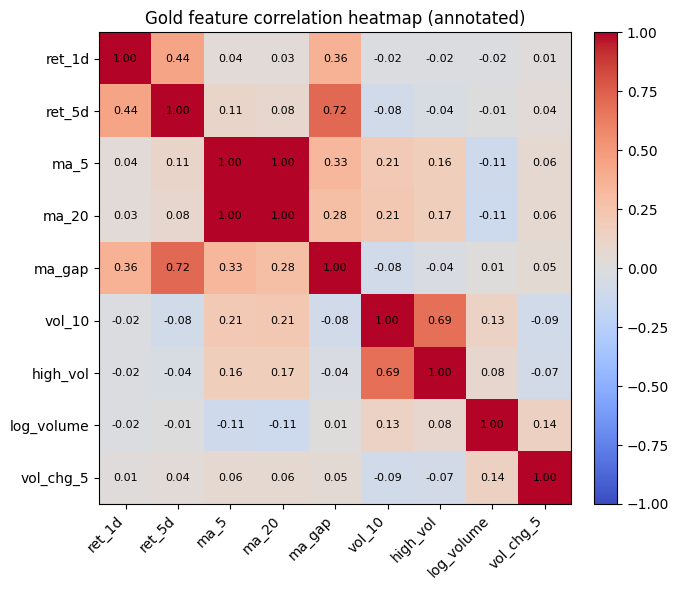

In [7]:
# Inspect engineered features for gold

print("Gold features head:")
print(gold_feat[["date"] + FEATURE_COLS + ["y_reg", "y_cls"]].head())

# Correlation matrix of features
corr_gold = gold_feat[FEATURE_COLS].corr()
print("\nGold feature correlation matrix:")
print(corr_gold.round(3))

# Correlation heatmap with numeric annotations
plt.figure(figsize=(7, 6))
im = plt.imshow(corr_gold, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)

plt.xticks(range(len(FEATURE_COLS)), FEATURE_COLS, rotation=45, ha="right")
plt.yticks(range(len(FEATURE_COLS)), FEATURE_COLS)
plt.title("Gold feature correlation heatmap (annotated)")

# Annotate each cell with the correlation value
for i in range(corr_gold.shape[0]):
    for j in range(corr_gold.shape[1]):
        val = corr_gold.iloc[i, j]
        plt.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8, color="black")

plt.tight_layout()
plt.show()

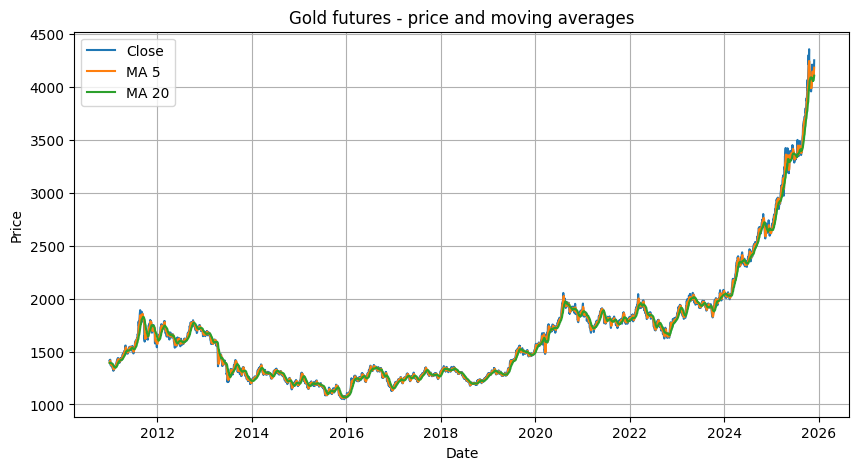

In [8]:
# Gold price with short and long moving averages

plt.figure(figsize=(10, 5))
plt.plot(gold_feat["date"], gold_feat["close"], label="Close")
plt.plot(gold_feat["date"], gold_feat["ma_5"],  label="MA 5")
plt.plot(gold_feat["date"], gold_feat["ma_20"], label="MA 20")
plt.title("Gold futures - price and moving averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

## Modeling setup (train/test split, helper functions)

In [9]:
# 5. Train/test split helper

def time_train_test_split(df, test_size=0.2):
    # Split the DataFrame by index without shuffling (time series)
    n = len(df)
    split_idx = int(n * (1 - test_size))
    train_df = df.iloc[:split_idx].copy()
    test_df  = df.iloc[split_idx:].copy()
    return train_df, test_df

In [10]:
# 6. Prepare X and y helper
def prepare_xy(df_feat):
    cols = FEATURE_COLS + ["y_reg", "y_cls"]
    
    # 1) keep only relevant columns
    df = df_feat[cols].copy()
    
    # 2) replace +/-inf with NaN
    df = df.replace([np.inf, -np.inf], np.nan)
    
    # 3) drop any remaining rows with NaN
    df = df.dropna().reset_index(drop=True)
    
    # 4) build numpy arrays
    X = df[FEATURE_COLS].values
    y_reg = df["y_reg"].values
    y_cls = df["y_cls"].values.astype(int)
    
    return X, y_reg, y_cls

## Model training & backtesting per asset

In [11]:
def _max_consecutive(mask):
    """Return the longest consecutive True run in a boolean array."""
    mask = np.asarray(mask, dtype=bool)
    if mask.size == 0:
        return 0
    # Count consecutive Trues
    best = cur = 0
    for v in mask:
        if v:
            cur += 1
            best = max(best, cur)
        else:
            cur = 0
    return int(best)

def compute_strategy_metrics(pred_dir, actual_ret, trading_days=252):
    """Compute strategy returns + backtest metrics.
    pred_dir is assumed to be the position for each day of actual_ret (long=1, flat=0).
    actual_ret is the next-day return series aligned with the prediction horizon.
    """
    pred_dir = np.asarray(pred_dir).astype(int)
    actual_ret = np.asarray(actual_ret, dtype=float)

    strat_ret = pred_dir * actual_ret
    equity_curve = (1 + strat_ret).cumprod()

    bh_ret = actual_ret
    bh_equity = (1 + bh_ret).cumprod()

    n = len(strat_ret)
    if n == 0:
        return strat_ret, equity_curve, bh_equity, {}

    # Annualized metrics
    ann_ret = (1 + strat_ret).prod()**(trading_days / n) - 1
    ann_vol = strat_ret.std(ddof=0) * np.sqrt(trading_days)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan

    bh_ann_ret = (1 + bh_ret).prod()**(trading_days / n) - 1
    bh_ann_vol = bh_ret.std(ddof=0) * np.sqrt(trading_days)
    bh_sharpe = bh_ann_ret / bh_ann_vol if bh_ann_vol > 0 else np.nan

    # Trades: count position changes (0->1 or 1->0)
    num_trades = int(np.sum(np.abs(np.diff(pred_dir)) > 0))

    # Win rate: fraction of days with positive strategy return when in position
    active_mask = pred_dir == 1
    wins = np.sum((strat_ret > 0) & active_mask)
    active_days = int(np.sum(active_mask))
    win_rate = wins / active_days if active_days > 0 else np.nan

    # Profit/loss streaks (consecutive days)
    max_win_streak = _max_consecutive(strat_ret > 0)
    max_loss_streak = _max_consecutive(strat_ret < 0)

    # Activity / "dead model" diagnostics
    active_pct = active_days / n if n > 0 else np.nan
    max_flat_days = _max_consecutive(pred_dir == 0)

    metrics = {
        "ann_ret": ann_ret,
        "ann_vol": ann_vol,
        "sharpe": sharpe,
        "bh_ann_ret": bh_ann_ret,
        "bh_ann_vol": bh_ann_vol,
        "bh_sharpe": bh_sharpe,
        "num_trades": num_trades,
        "win_rate": win_rate,
        "max_win_streak": max_win_streak,
        "max_loss_streak": max_loss_streak,
        "active_pct": active_pct,
        "max_flat_days": max_flat_days
    }

    return strat_ret, equity_curve, bh_equity, metrics

In [14]:
# 8. Main modeling function

def run_models_for_asset(df_feat, asset_name, test_size=0.2, plot_equity=True):
    print(f"\n=== {asset_name.upper()} ===")

    # Adaptive long/flat signal to avoid prolonged "no-trade" periods
    def adaptive_long_signal(score, window=126, q=0.60, min_periods=30):
        s = pd.Series(score).astype(float)
        thr = s.shift(1).rolling(window=window, min_periods=min_periods).quantile(q)
        thr = thr.fillna(s.shift(1).expanding(min_periods=min_periods).quantile(q))
        return (s > thr).astype(int).values

    # -------------------------
    # Train / test split
    # -------------------------
    train_df, test_df = time_train_test_split(df_feat, test_size=test_size)

    X_train, y_train_reg, y_train_cls = prepare_xy(train_df)
    X_test,  y_test_reg,  y_test_cls  = prepare_xy(test_df)

    # -------------------------
    # 8.1 Random Forest (regression)
    # -------------------------
    rf = RandomForestRegressor(
        n_estimators=400,
        max_depth=5,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train_reg)

    rf_pred_ret = rf.predict(X_test)
    rf_pred_dir = adaptive_long_signal(rf_pred_ret)

    rf_acc = accuracy_score(y_test_cls, rf_pred_dir)
    print(f"RF sign accuracy: {rf_acc:.3f}")

    # -------------------------
    # 8.2 KNN classifier
    # -------------------------
    knn_clf = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=15))
    ])
    knn_clf.fit(X_train, y_train_cls)

    try:
        knn_pred_prob = knn_clf.predict_proba(X_test)[:, 1]
    except Exception:
        knn_pred_prob = knn_clf.predict(X_test).astype(float)

    knn_pred_dir = adaptive_long_signal(knn_pred_prob)

    knn_acc = accuracy_score(y_test_cls, knn_pred_dir)
    print(f"KNN accuracy:     {knn_acc:.3f}")

    # -------------------------
    # 8.3 Ensemble
    # -------------------------
    rf_z  = (pd.Series(rf_pred_ret) - np.mean(rf_pred_ret)) / (np.std(rf_pred_ret) + 1e-9)
    knn_z = (pd.Series(knn_pred_prob) - np.mean(knn_pred_prob)) / (np.std(knn_pred_prob) + 1e-9)

    ensemble_score = 0.5 * rf_z + 0.5 * knn_z
    ensemble_dir   = adaptive_long_signal(ensemble_score.values)

    ens_acc = accuracy_score(y_test_cls, ensemble_dir)
    print(f"Ensemble accuracy:{ens_acc:.3f}")

    # -------------------------
    # 8.4 XGBoost
    # -------------------------
    xgb = XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
    xgb.fit(X_train, y_train_cls)

    xgb_pred_prob = xgb.predict_proba(X_test)[:, 1]
    xgb_pred_dir  = adaptive_long_signal(xgb_pred_prob)

    xgb_acc = accuracy_score(y_test_cls, xgb_pred_dir)
    print(f"XGBoost accuracy: {xgb_acc:.3f}")

    # -------------------------
    # 8.5 Backtesting
    # -------------------------
    results = {
        "rf_sign": rf_pred_dir,
        "knn": knn_pred_dir,
        "ensemble": ensemble_dir,
        "xgb": xgb_pred_dir
    }

    out = {}

    for name, pred in results.items():
        strat_ret, eq, bh_eq, metr = compute_strategy_metrics(pred, y_test_reg)

        # Trading chart (aligned indexing)
        if plot_equity:
            plot_df = test_df.iloc[-len(pred):].copy()
            plot_df["pred"] = pred

            entries = plot_df["pred"].diff() == 1
            exits   = plot_df["pred"].diff() == -1

            plt.figure(figsize=(11, 4))
            plt.plot(plot_df["date"], plot_df["close"], label="Close")
            plt.scatter(plot_df.loc[entries, "date"],
                        plot_df.loc[entries, "close"],
                        marker="^", label="Entry")
            plt.scatter(plot_df.loc[exits, "date"],
                        plot_df.loc[exits, "close"],
                        marker="v", label="Exit")
            plt.title(f"{asset_name.title()} – Trading chart ({name})")
            plt.xlabel("Date")
            plt.ylabel("Price")
            plt.legend()
            plt.grid(alpha=0.3)
            plt.tight_layout()
            plt.show()

        out[name] = {
            "pred_dir": pred,
            "strat_ret": strat_ret,
            "equity": eq,
            "bh_equity": bh_eq,
            "metrics": metr
        }

    # -------------------------
    # Equity curves
    # -------------------------
    if plot_equity:
        plt.figure(figsize=(10, 6))
        for name, res in out.items():
            plt.plot(res["equity"], label=name)
        first_key = list(out.keys())[0]
        plt.plot(out[first_key]["bh_equity"], "--", label="buy & hold")
        plt.title(f"{asset_name.upper()} – Equity Curves (Test Period)")
        plt.xlabel("Time")
        plt.ylabel("Equity")
        plt.legend()
        plt.grid(True)
        plt.show()

    # -------------------------
    # Feature importance
    # -------------------------
    feat_imp = pd.DataFrame({
        "feature": FEATURE_COLS,
        "rf_importance": rf.feature_importances_,
        "xgb_importance": xgb.feature_importances_
    }).sort_values("xgb_importance", ascending=False)

    print("\nTop features by XGBoost importance:")
    print(feat_imp.head(10))

    print("\nXGBoost classification report:")
    print(classification_report(y_test_cls, xgb_pred_dir, digits=3))

    # Summary
    summary = {
        "asset": asset_name,
        "acc_rf_sign": rf_acc,
        "acc_knn": knn_acc,
        "acc_ensemble": ens_acc,
        "acc_xgb": xgb_acc,
        "results": out,
        "feature_importances": feat_imp
    }

    return summary



=== GOLD ===
RF sign accuracy: 0.504
KNN accuracy:     0.487
Ensemble accuracy:0.490
XGBoost accuracy: 0.507


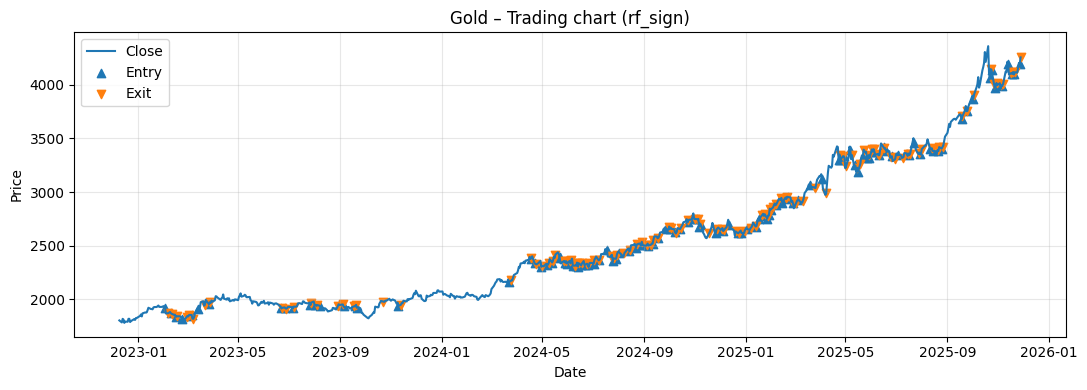

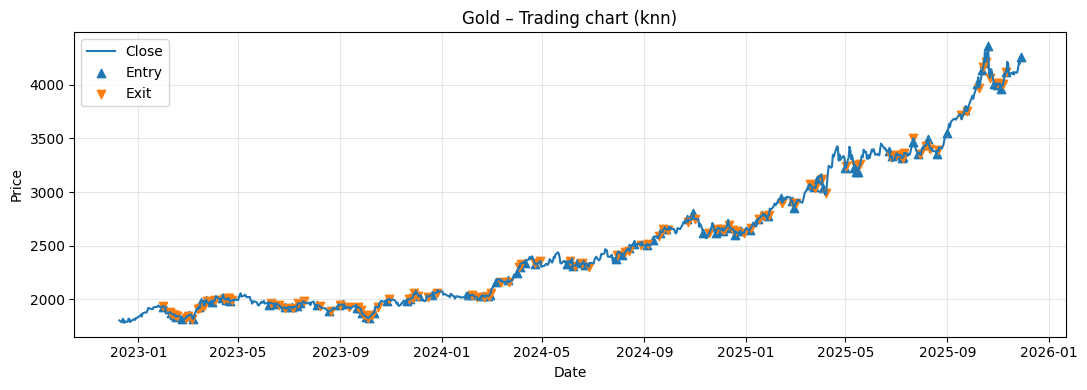

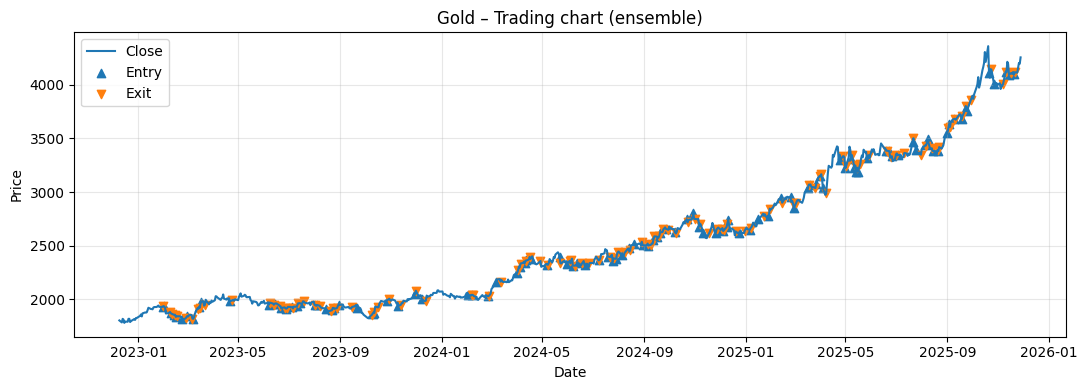

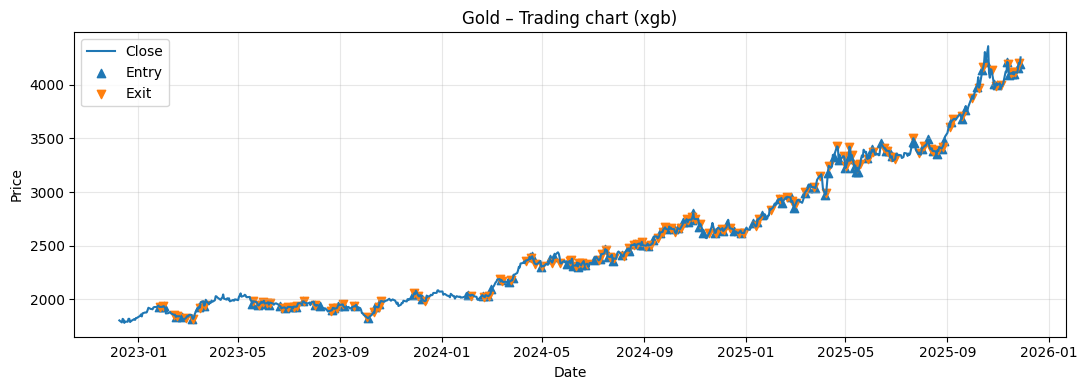

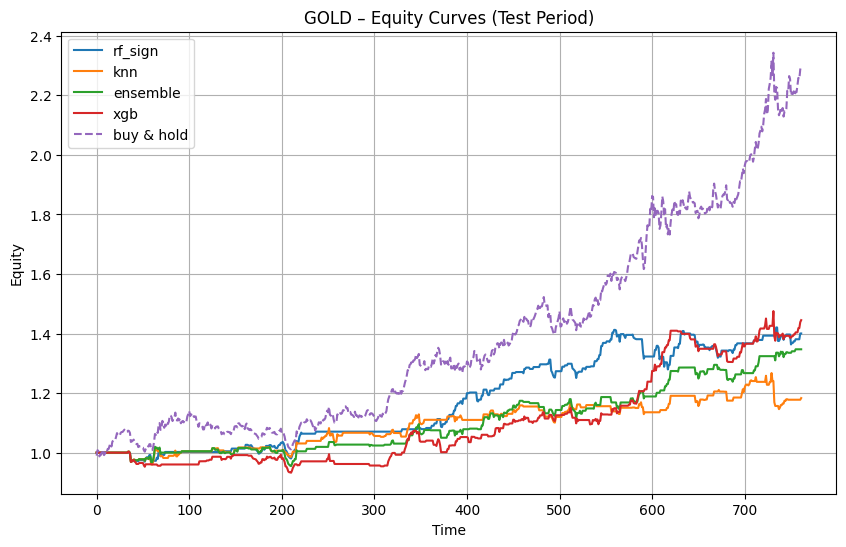


Top features by XGBoost importance:
      feature  rf_importance  xgb_importance
8   vol_chg_5       0.094889        0.119061
7  log_volume       0.062536        0.116504
0      ret_1d       0.212522        0.116067
5      vol_10       0.153922        0.114793
2        ma_5       0.088309        0.112953
4      ma_gap       0.217549        0.112804
1      ret_5d       0.121424        0.111766
3       ma_20       0.048773        0.109667
6    high_vol       0.000077        0.086385

XGBoost classification report:
              precision    recall  f1-score   support

           0      0.470     0.663     0.550       347
           1      0.571     0.376     0.453       415

    accuracy                          0.507       762
   macro avg      0.521     0.519     0.502       762
weighted avg      0.525     0.507     0.498       762


=== SILVER ===
RF sign accuracy: 0.500
KNN accuracy:     0.470
Ensemble accuracy:0.451
XGBoost accuracy: 0.503


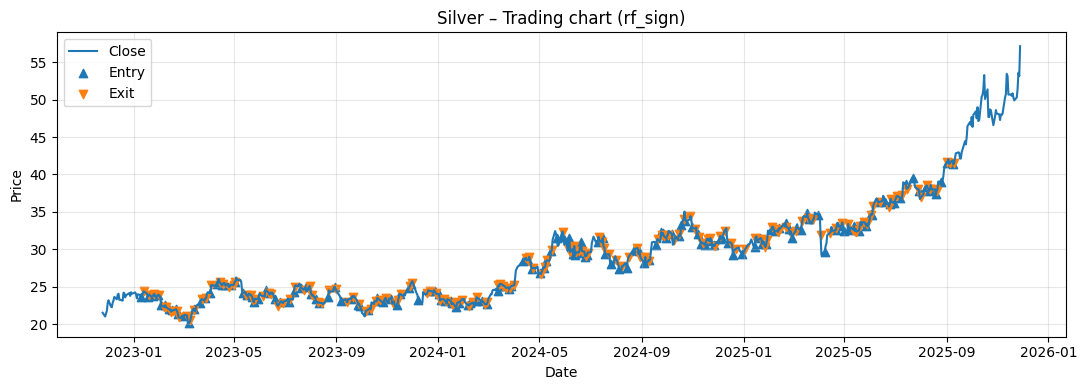

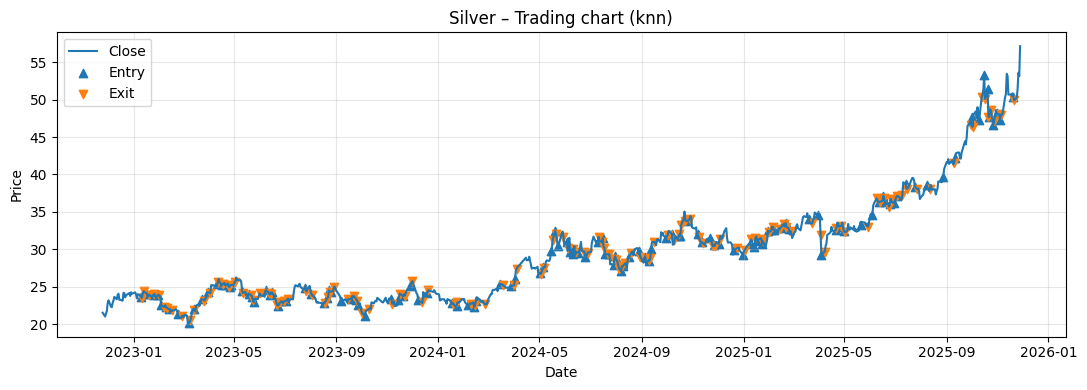

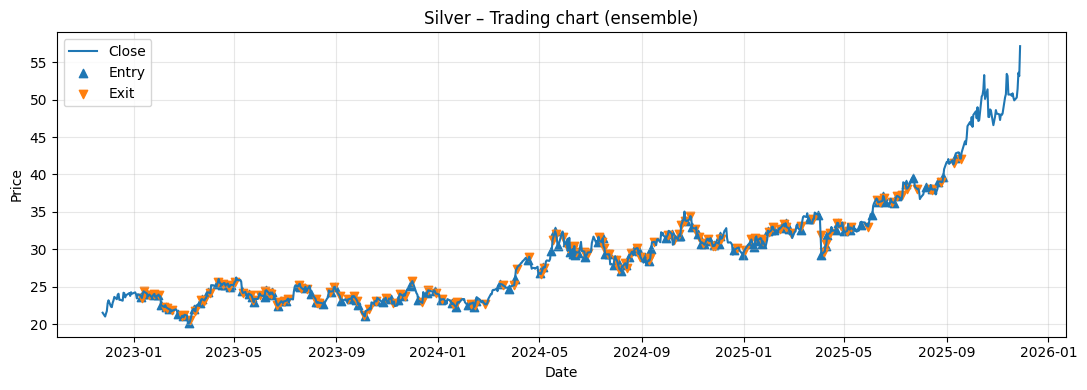

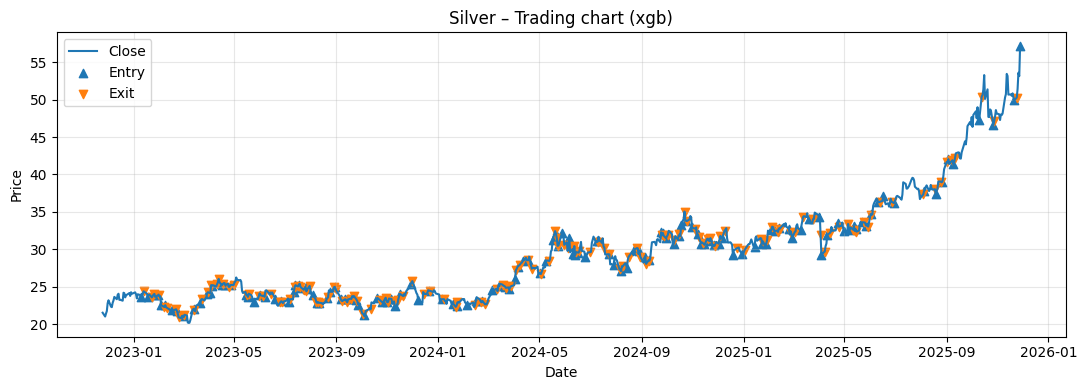

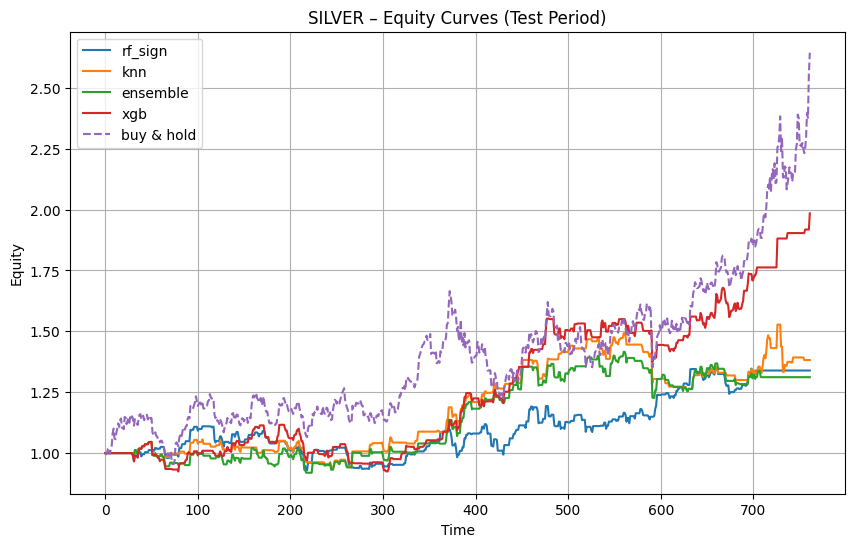


Top features by XGBoost importance:
      feature  rf_importance  xgb_importance
0      ret_1d       0.255520        0.115907
3       ma_20       0.163514        0.114542
1      ret_5d       0.115722        0.112327
8   vol_chg_5       0.059202        0.112058
5      vol_10       0.081585        0.111700
7  log_volume       0.050771        0.110608
4      ma_gap       0.162787        0.108109
6    high_vol       0.000185        0.107609
2        ma_5       0.110714        0.107141

XGBoost classification report:
              precision    recall  f1-score   support

           0      0.470     0.621     0.535       351
           1      0.554     0.401     0.465       411

    accuracy                          0.503       762
   macro avg      0.512     0.511     0.500       762
weighted avg      0.515     0.503     0.497       762


=== COPPER ===
RF sign accuracy: 0.500
KNN accuracy:     0.479
Ensemble accuracy:0.503
XGBoost accuracy: 0.497


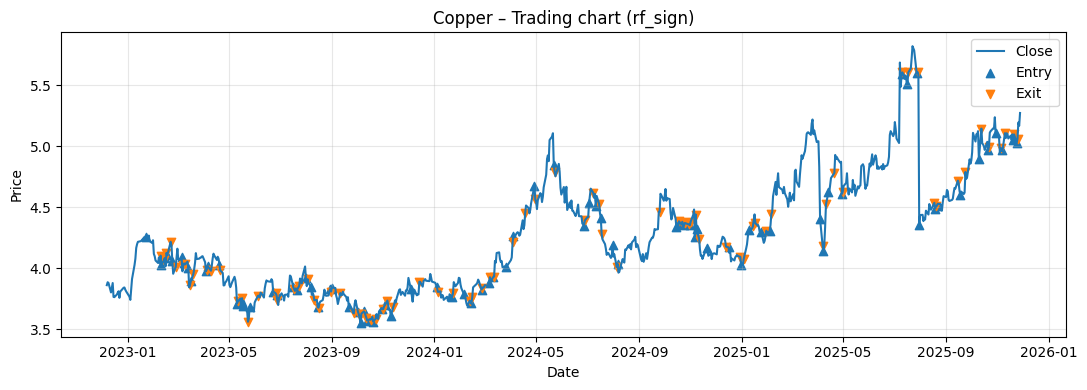

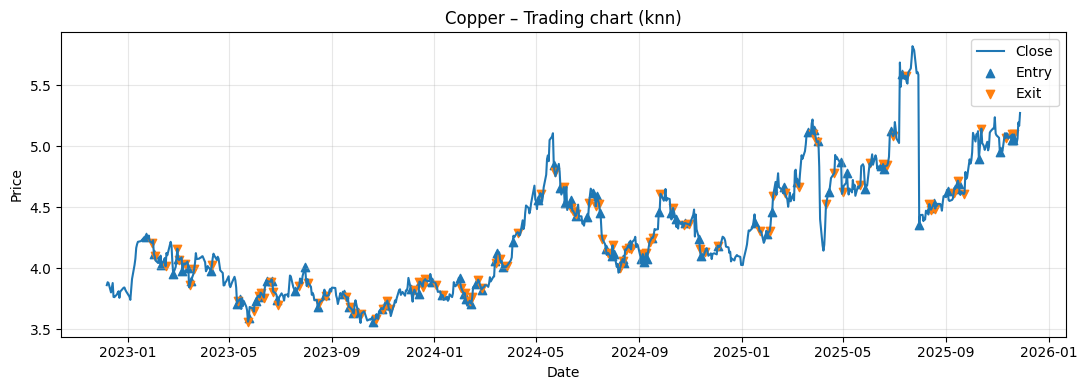

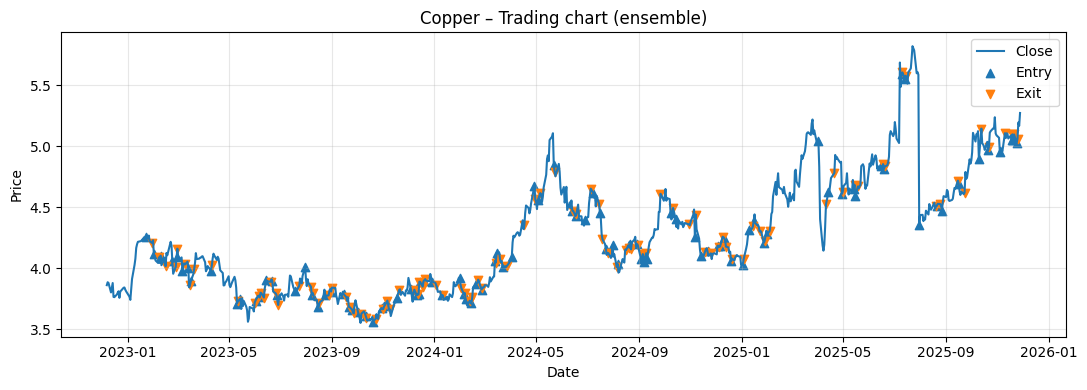

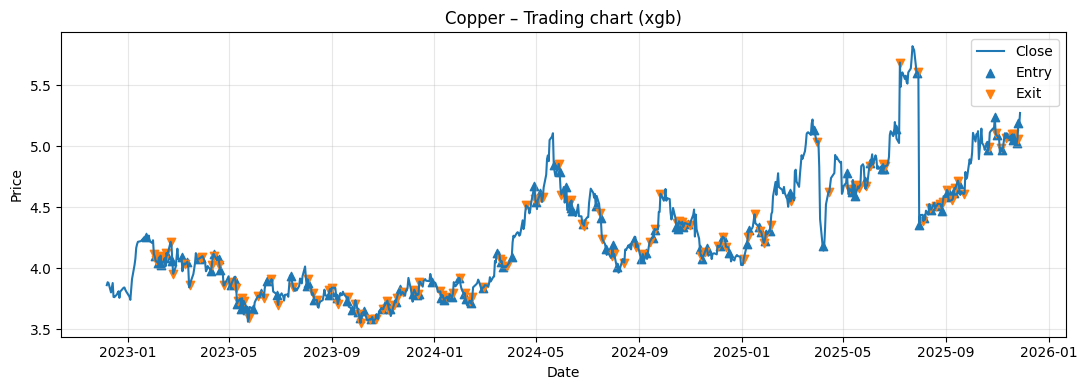

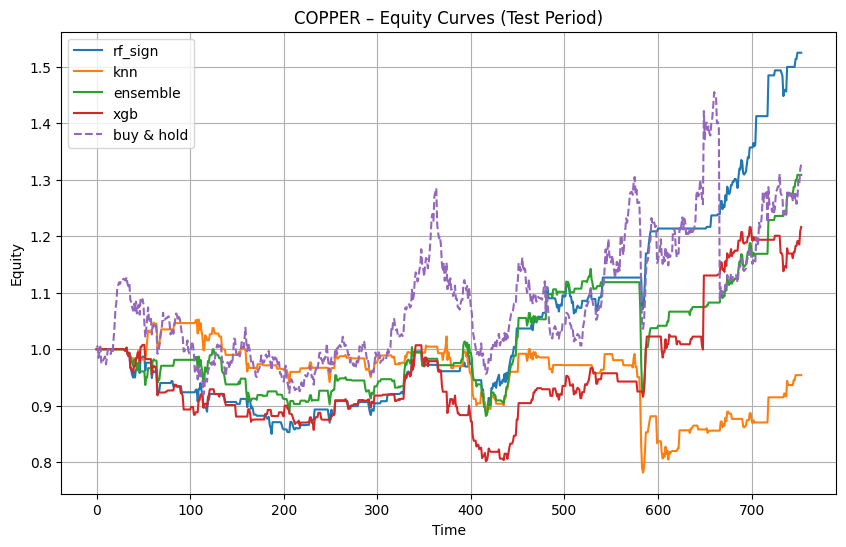


Top features by XGBoost importance:
      feature  rf_importance  xgb_importance
3       ma_20       0.078616        0.120894
2        ma_5       0.126878        0.119845
0      ret_1d       0.148690        0.116224
7  log_volume       0.090714        0.113602
5      vol_10       0.182874        0.113386
1      ret_5d       0.125294        0.111433
4      ma_gap       0.159347        0.107998
8   vol_chg_5       0.086901        0.105083
6    high_vol       0.000686        0.091535

XGBoost classification report:
              precision    recall  f1-score   support

           0      0.480     0.636     0.547       360
           1      0.527     0.371     0.435       394

    accuracy                          0.497       754
   macro avg      0.504     0.503     0.491       754
weighted avg      0.505     0.497     0.489       754



In [15]:
# 9. Run models for all three metals

gold_summary   = run_models_for_asset(gold_feat,   "gold",   test_size=0.2, plot_equity=True)
silver_summary = run_models_for_asset(silver_feat, "silver", test_size=0.2, plot_equity=True)
copper_summary = run_models_for_asset(copper_feat, "copper", test_size=0.2, plot_equity=True)

## Summary tables & comparison plots

In [16]:
# Performance metrics across assets 

def extract_perf(summary):
    asset = summary["asset"]
    rows = []
    for model_name, res in summary["results"].items():
        m = res["metrics"]
        rows.append({
            "asset": asset,
            "model": model_name,
            "ann_ret": m.get("ann_ret", np.nan),
            "ann_vol": m.get("ann_vol", np.nan),
            "sharpe": m.get("sharpe", np.nan),
            "bh_ann_ret": m.get("bh_ann_ret", np.nan),
            "bh_sharpe": m.get("bh_sharpe", np.nan),
            "num_trades": m.get("num_trades", np.nan),
            "win_rate": m.get("win_rate", np.nan),
            "max_flat_days": m.get("max_flat_days", np.nan),
            "active_pct": m.get("active_pct", np.nan),
            "max_loss_streak": m.get("max_loss_streak", np.nan),
            "max_win_streak": m.get("max_win_streak", np.nan)
        })
    return rows

perf_rows = []
for s in [gold_summary, silver_summary, copper_summary]:
    perf_rows.extend(extract_perf(s))

perf_table = pd.DataFrame(perf_rows)
print("\nPerformance metrics (test period):")
print(perf_table.round(3))


Performance metrics (test period):
     asset     model  ann_ret  ann_vol  sharpe  bh_ann_ret  bh_sharpe  \
0     gold   rf_sign    0.118    0.090   1.308       0.317      1.924   
1     gold       knn    0.057    0.090   0.633       0.317      1.924   
2     gold  ensemble    0.104    0.084   1.229       0.317      1.924   
3     gold       xgb    0.129    0.098   1.319       0.317      1.924   
4   silver   rf_sign    0.101    0.156   0.651       0.379      1.299   
5   silver       knn    0.113    0.169   0.669       0.379      1.299   
6   silver  ensemble    0.094    0.167   0.563       0.379      1.299   
7   silver       xgb    0.254    0.172   1.476       0.379      1.299   
8   copper   rf_sign    0.151    0.125   1.207       0.099      0.368   
9   copper       knn   -0.016    0.138  -0.113       0.099      0.368   
10  copper  ensemble    0.094    0.135   0.696       0.099      0.368   
11  copper       xgb    0.068    0.146   0.463       0.099      0.368   

    num_trades

In [17]:
# Collect accuracy numbers across metals

rows = []
for s in [gold_summary, silver_summary, copper_summary]:
    rows.append({
        "asset": s["asset"],
        "acc_rf_sign": s["acc_rf_sign"],
        "acc_knn": s["acc_knn"],
        "acc_ensemble": s["acc_ensemble"],
        "acc_xgb": s["acc_xgb"]
    })

acc_table = pd.DataFrame(rows)
print("\nModel accuracies by asset:")
print(acc_table.round(3))


Model accuracies by asset:
    asset  acc_rf_sign  acc_knn  acc_ensemble  acc_xgb
0    gold        0.504    0.487         0.490    0.507
1  silver        0.500    0.470         0.451    0.503
2  copper        0.500    0.479         0.503    0.497


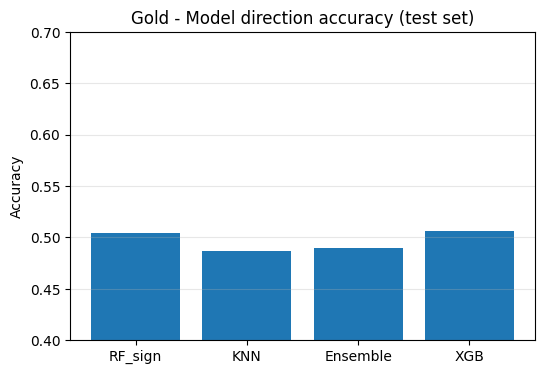

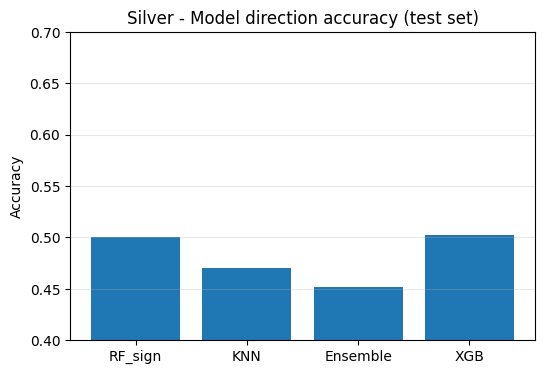

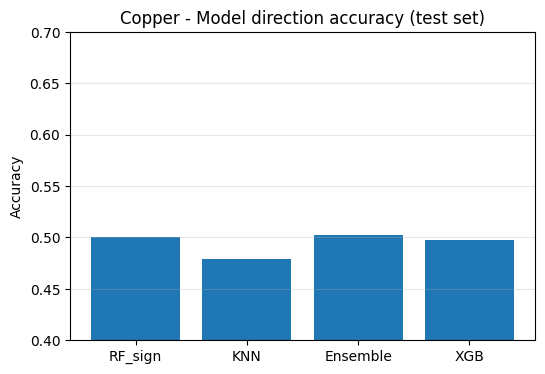

In [18]:
# Accuracy comparison for Gold

gold_acc = acc_table[acc_table["asset"] == "gold"].iloc[0]
models = ["RF_sign", "KNN", "Ensemble", "XGB"]
vals   = [
    gold_acc["acc_rf_sign"],
    gold_acc["acc_knn"],
    gold_acc["acc_ensemble"],
    gold_acc["acc_xgb"],
]

plt.figure(figsize=(6,4))
plt.bar(models, vals)
plt.ylim(0.4, 0.7)
plt.title("Gold - Model direction accuracy (test set)")
plt.ylabel("Accuracy")
plt.grid(axis="y", alpha=0.3)
plt.show()

# Example for accuracy comparison for Gold

silver_acc = acc_table[acc_table["asset"] == "silver"].iloc[0]
models = ["RF_sign", "KNN", "Ensemble", "XGB"]
vals   = [
    silver_acc["acc_rf_sign"],
    silver_acc["acc_knn"],
    silver_acc["acc_ensemble"],
    silver_acc["acc_xgb"],
]

plt.figure(figsize=(6,4))
plt.bar(models, vals)
plt.ylim(0.4, 0.7)
plt.title("Silver - Model direction accuracy (test set)")
plt.ylabel("Accuracy")
plt.grid(axis="y", alpha=0.3)
plt.show()

# Example for accuracy comparison for Gold

copper_acc = acc_table[acc_table["asset"] == "copper"].iloc[0]
models = ["RF_sign", "KNN", "Ensemble", "XGB"]
vals   = [
    copper_acc["acc_rf_sign"],
    copper_acc["acc_knn"],
    copper_acc["acc_ensemble"],
    copper_acc["acc_xgb"],
]

plt.figure(figsize=(6,4))
plt.bar(models, vals)
plt.ylim(0.4, 0.7)
plt.title("Copper - Model direction accuracy (test set)")
plt.ylabel("Accuracy")
plt.grid(axis="y", alpha=0.3)
plt.show()

